In [ ]:
R.version.string

[1] "R version 4.6.0 (2026-04-24)"

In [ ]:
# Instalando os pacotes necessários

install.packages('tidyverse') # manipulacao de dados
install.packages('ggplot2') # visualizacao
install.packages('cowplot') # unir graficos
install.packages('caret') # modelos estatisticos
install.packages('corrplot') # matriz de correlacao
install.packages('rattle') # impressao de arvore de decisao

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(caret)
library(tidyverse)
library(ggplot2)
library(cowplot)
library(corrplot)
library(rattle)

Carregar os dados para o Data Frame

In [ ]:
dados <-read.csv("VIVO_CHURN.csv", stringsAsFactors = T)

Visualizar os dados

In [ ]:
glimpse(dados)
summary(dados)

Rows: 7,043
Columns: 21
$ customerID       <fct> 7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW, 9237-…
$ gender           <fct> Female, Male, Male, Male, Female, Female, Male, Femal…
$ SeniorCitizen    <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Partner          <fct> Yes, No, No, No, No, No, No, No, Yes, No, Yes, No, Ye…
$ Dependents       <fct> No, No, No, No, No, No, Yes, No, No, Yes, Yes, No, No…
$ tenure           <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, 62, 13, 16, 58, 49, 2…
$ PhoneService     <fct> No, Yes, Yes, No, Yes, Yes, Yes, No, Yes, Yes, Yes, Y…
$ MultipleLines    <fct> No phone service, No, No, No phone service, No, Yes, …
$ InternetService  <fct> DSL, DSL, DSL, DSL, Fiber optic, Fiber optic, Fiber o…
$ OnlineSecurity   <fct> No, Yes, Yes, Yes, No, No, No, Yes, No, Yes, Yes, No …
$ OnlineBackup     <fct> Yes, No, Yes, No, No, No, Yes, No, No, Yes, No, No in…
$ DeviceProtection <fct> No, Yes, No, Yes, No, Yes, No, No, Yes, No, No, No in…
$ TechSupport   

      customerID      gender     SeniorCitizen    Partner    Dependents
 0002-ORFBO:   1   Female:3488   Min.   :0.0000   No :3641   No :4933  
 0003-MKNFE:   1   Male  :3555   1st Qu.:0.0000   Yes:3402   Yes:2110  
 0004-TLHLJ:   1                 Median :0.0000                        
 0011-IGKFF:   1                 Mean   :0.1621                        
 0013-EXCHZ:   1                 3rd Qu.:0.0000                        
 0013-MHZWF:   1                 Max.   :1.0000                        
 (Other)   :7037                                                       
     tenure      PhoneService          MultipleLines     InternetService
 Min.   : 0.00   No : 682     No              :3390   DSL        :2421  
 1st Qu.: 9.00   Yes:6361     No phone service: 682   Fiber optic:3096  
 Median :29.00                Yes             :2971   No         :1526  
 Mean   :32.37                                                          
 3rd Qu.:55.00                                             

Verificar valores nulos e retirar

In [ ]:
colSums(is.na(dados)) #se nulo
dados_1 <- dados[!is.na(dados$TotalCharges),] #diferente de nulo para o novo data frame
colSums(is.na(dados_1))
glimpse(dados_1)

customerID           gender    SeniorCitizen          Partner 
               0                0                0                0 
      Dependents           tenure     PhoneService    MultipleLines 
               0                0                0                0 
 InternetService   OnlineSecurity     OnlineBackup DeviceProtection 
               0                0                0                0 
     TechSupport      StreamingTV  StreamingMovies         Contract 
               0                0                0                0 
PaperlessBilling    PaymentMethod   MonthlyCharges     TotalCharges 
               0                0                0               11 
           Churn 
               0

customerID           gender    SeniorCitizen          Partner 
               0                0                0                0 
      Dependents           tenure     PhoneService    MultipleLines 
               0                0                0                0 
 InternetService   OnlineSecurity     OnlineBackup DeviceProtection 
               0                0                0                0 
     TechSupport      StreamingTV  StreamingMovies         Contract 
               0                0                0                0 
PaperlessBilling    PaymentMethod   MonthlyCharges     TotalCharges 
               0                0                0                0 
           Churn 
               0

Rows: 7,032
Columns: 21
$ customerID       <fct> 7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW, 9237-…
$ gender           <fct> Female, Male, Male, Male, Female, Female, Male, Femal…
$ SeniorCitizen    <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Partner          <fct> Yes, No, No, No, No, No, No, No, Yes, No, Yes, No, Ye…
$ Dependents       <fct> No, No, No, No, No, No, Yes, No, No, Yes, Yes, No, No…
$ tenure           <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, 62, 13, 16, 58, 49, 2…
$ PhoneService     <fct> No, Yes, Yes, No, Yes, Yes, Yes, No, Yes, Yes, Yes, Y…
$ MultipleLines    <fct> No phone service, No, No, No phone service, No, Yes, …
$ InternetService  <fct> DSL, DSL, DSL, DSL, Fiber optic, Fiber optic, Fiber o…
$ OnlineSecurity   <fct> No, Yes, Yes, Yes, No, No, No, Yes, No, Yes, Yes, No …
$ OnlineBackup     <fct> Yes, No, Yes, No, No, No, Yes, No, No, Yes, No, No in…
$ DeviceProtection <fct> No, Yes, No, Yes, No, Yes, No, No, Yes, No, No, No in…
$ TechSupport   

## Pre processamento

Outliers

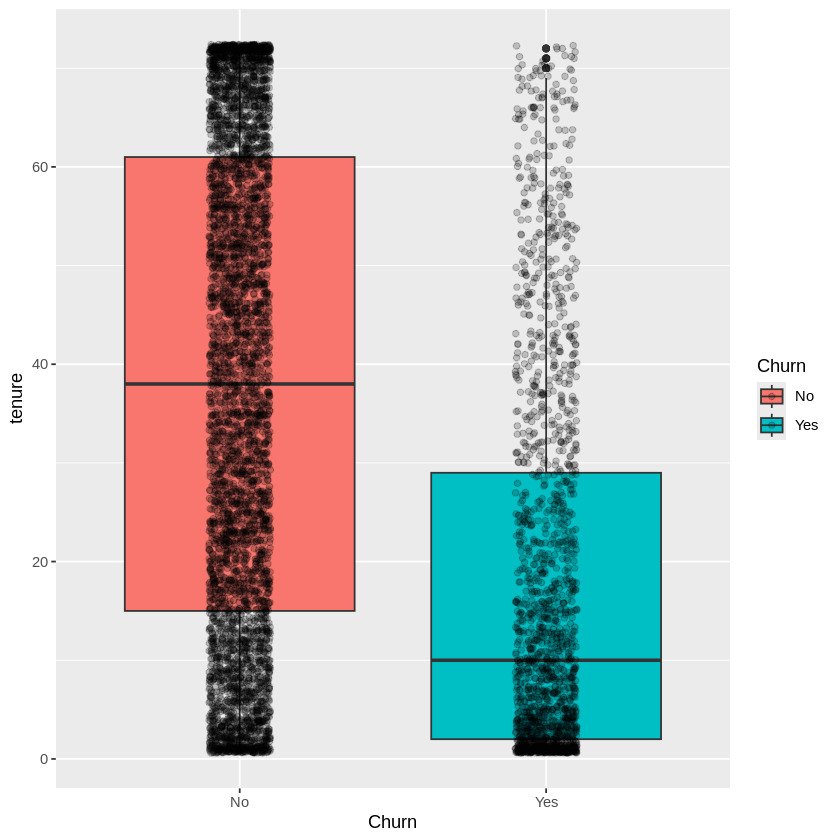

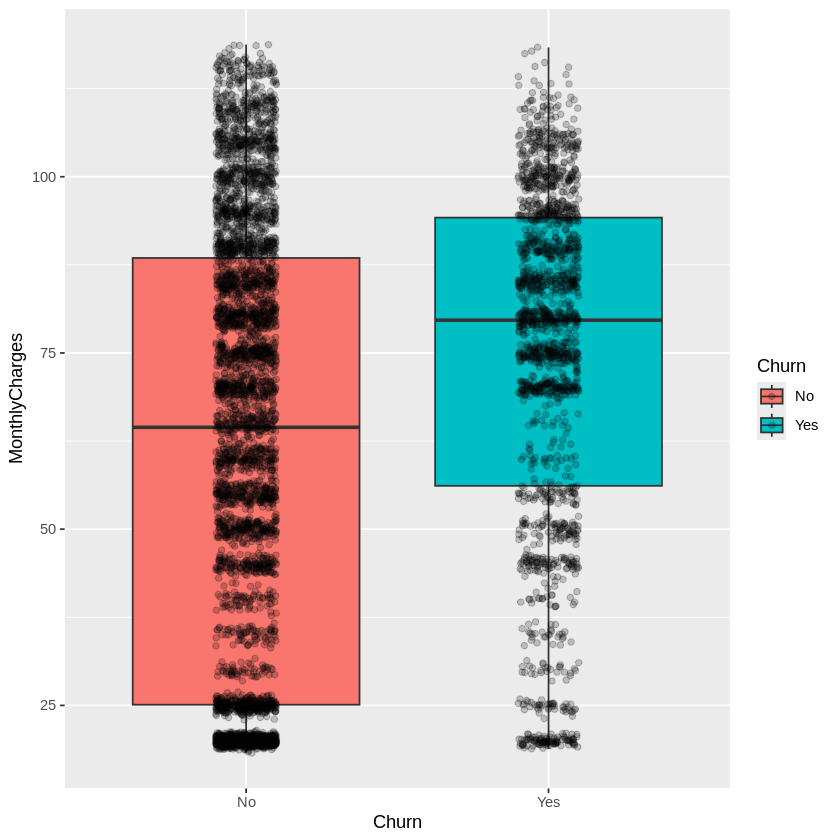

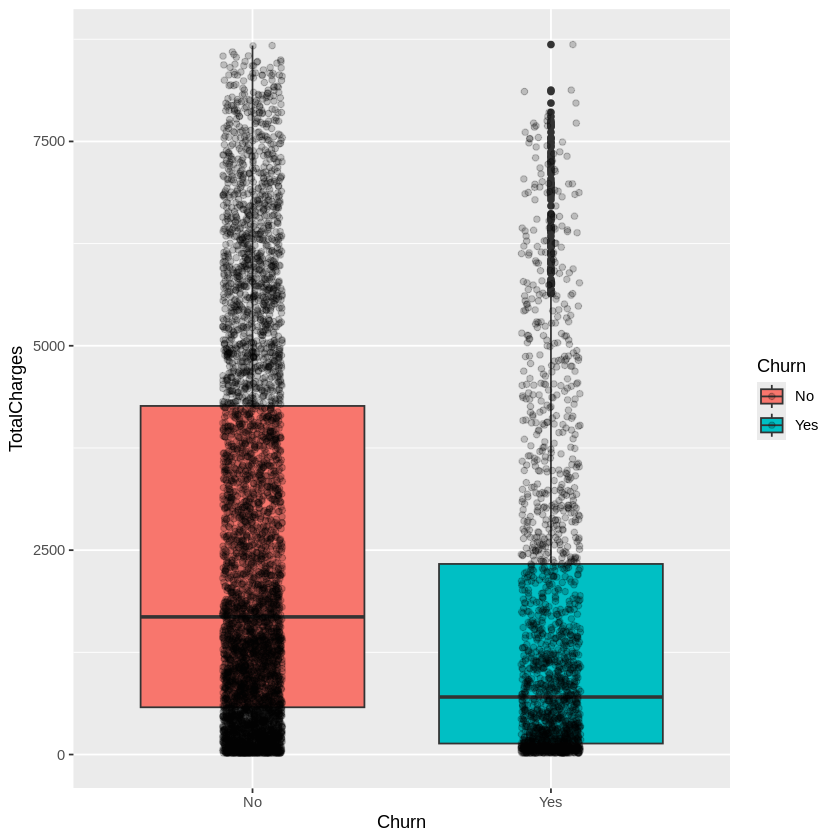

In [ ]:
dados_1 %>%
  ggplot(aes(x=Churn, y=tenure, fill=Churn)) +
  geom_boxplot() + geom_jitter(width = 0.1,alpha=0.2)

dados_1 %>%
  ggplot(aes(x=Churn, y=MonthlyCharges, fill=Churn)) +
  geom_boxplot() + geom_jitter(width = 0.1,alpha=0.2)

dados_1 %>%
  ggplot(aes(x=Churn, y=TotalCharges, fill=Churn)) +
  geom_boxplot() + geom_jitter(width = 0.1,alpha=0.2)

Verificar a classificacao das variaveis categoricas

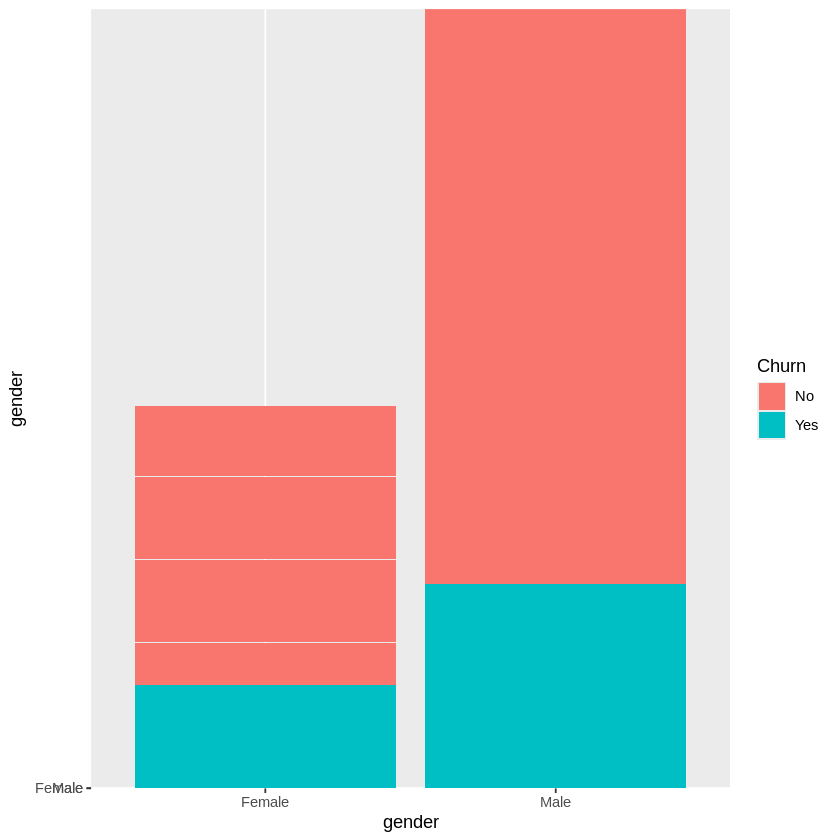

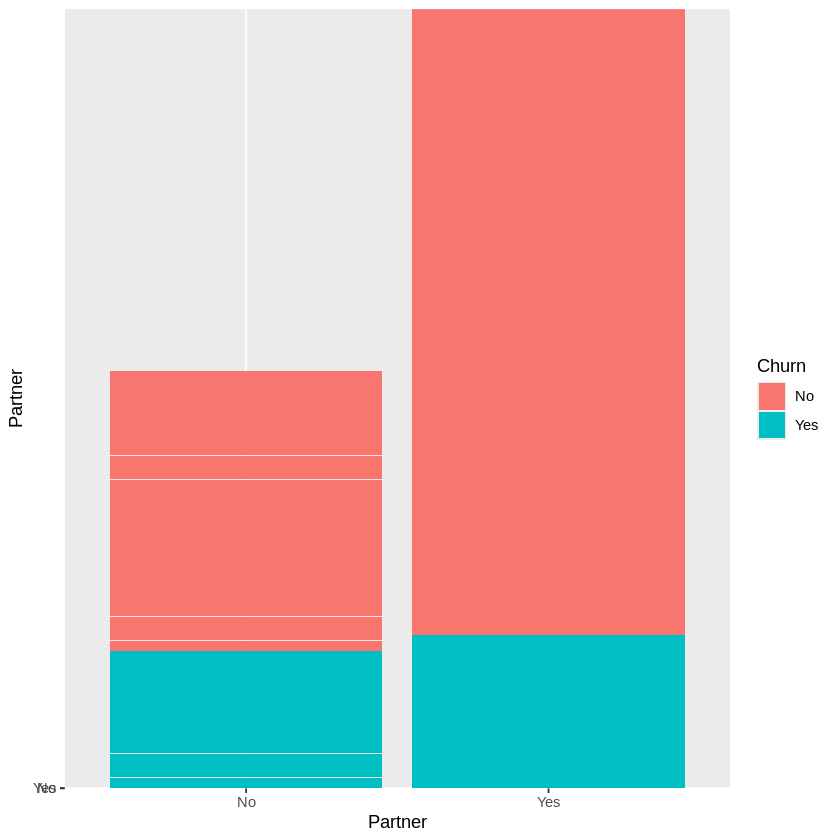

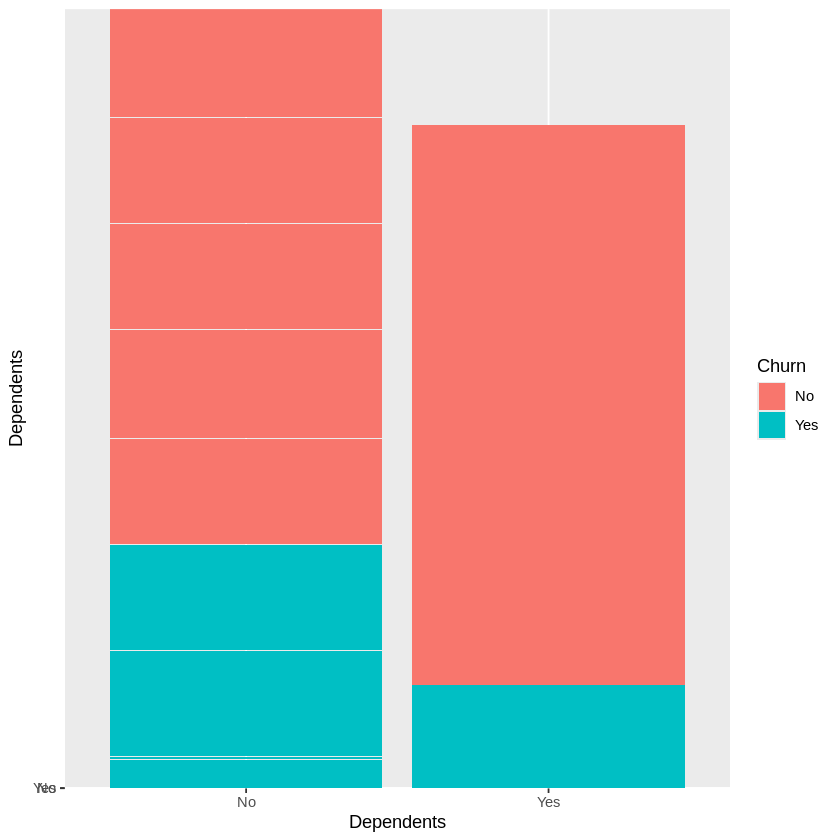

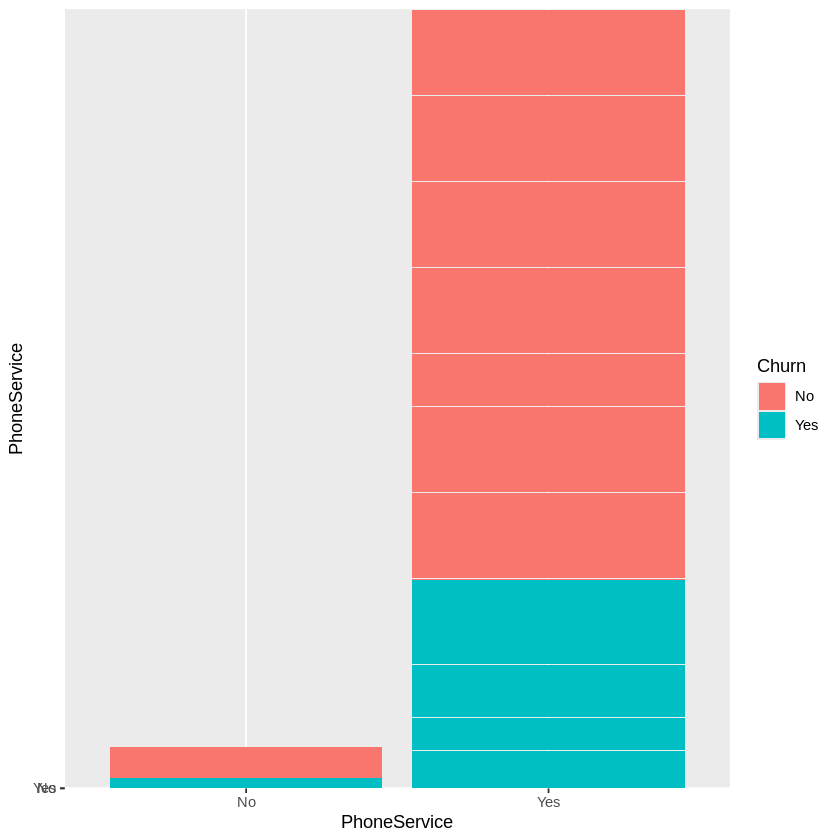

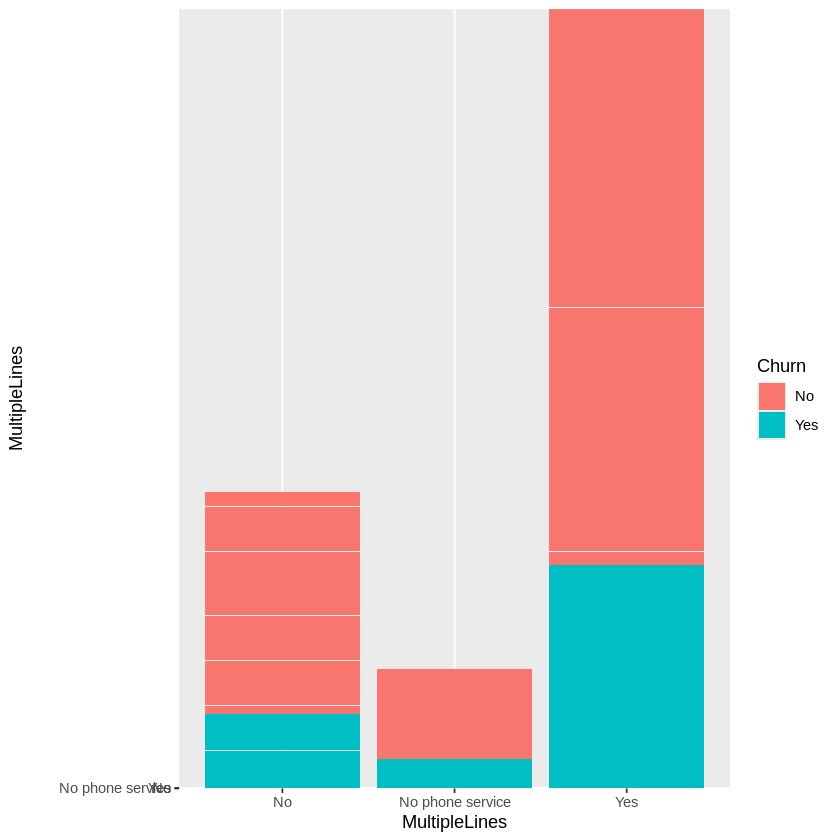

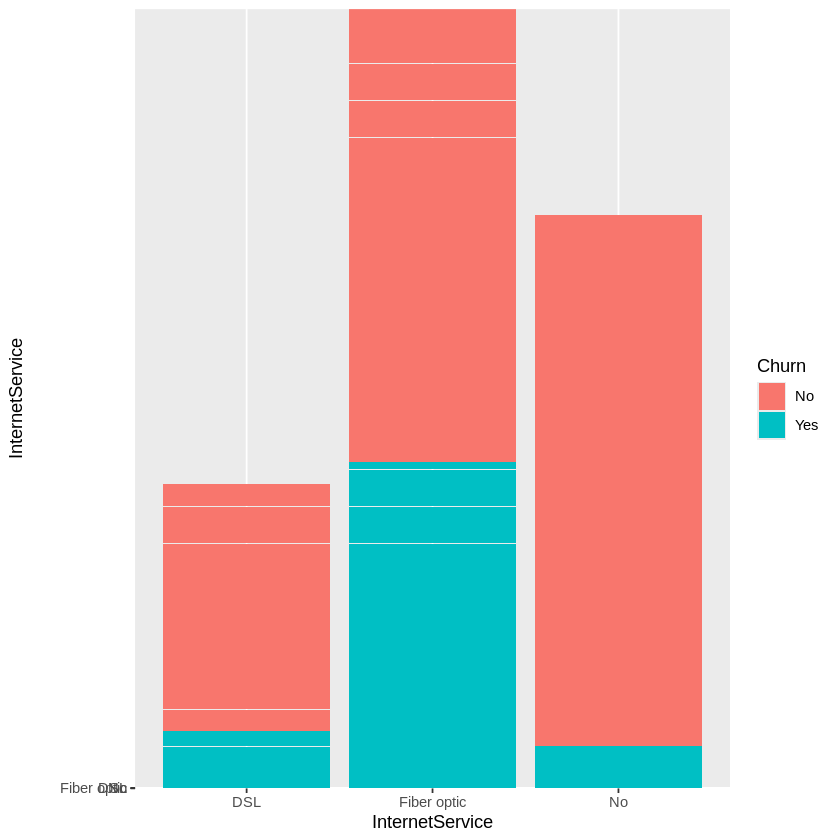

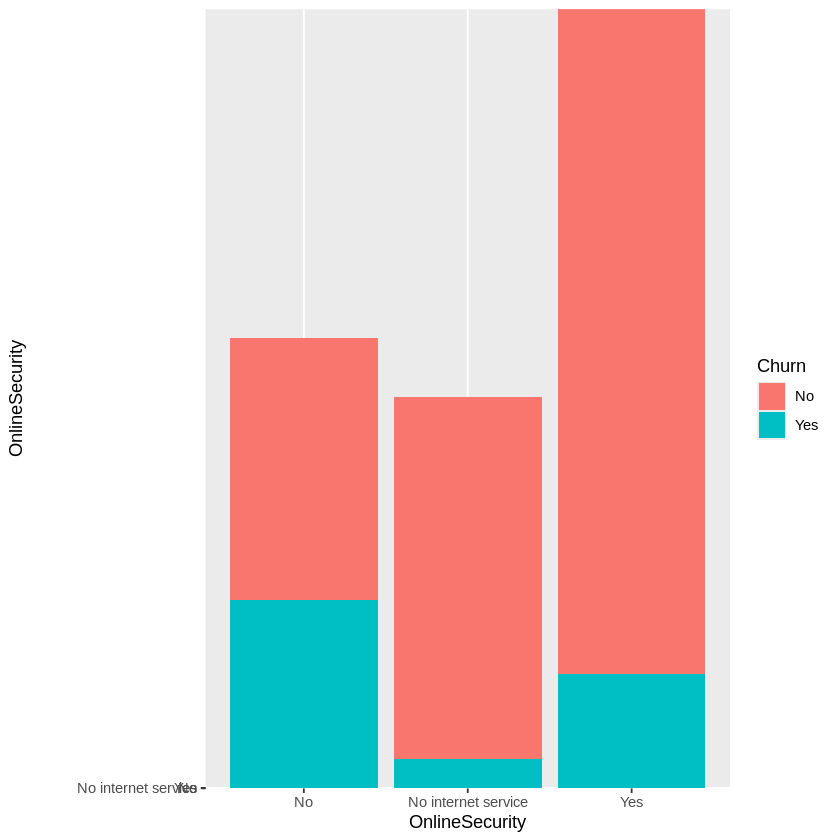

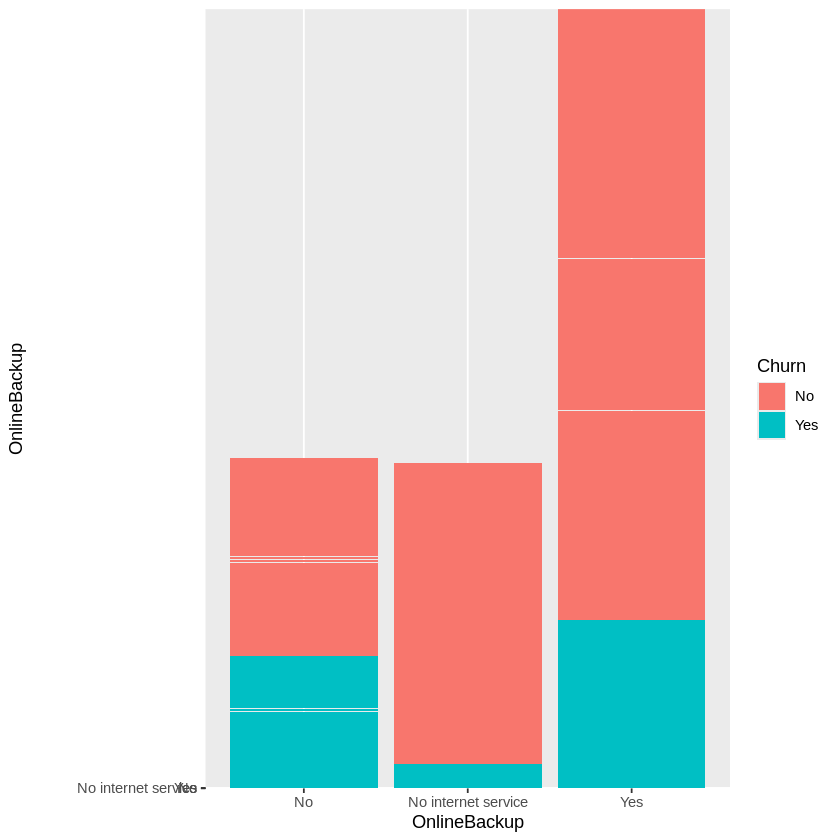

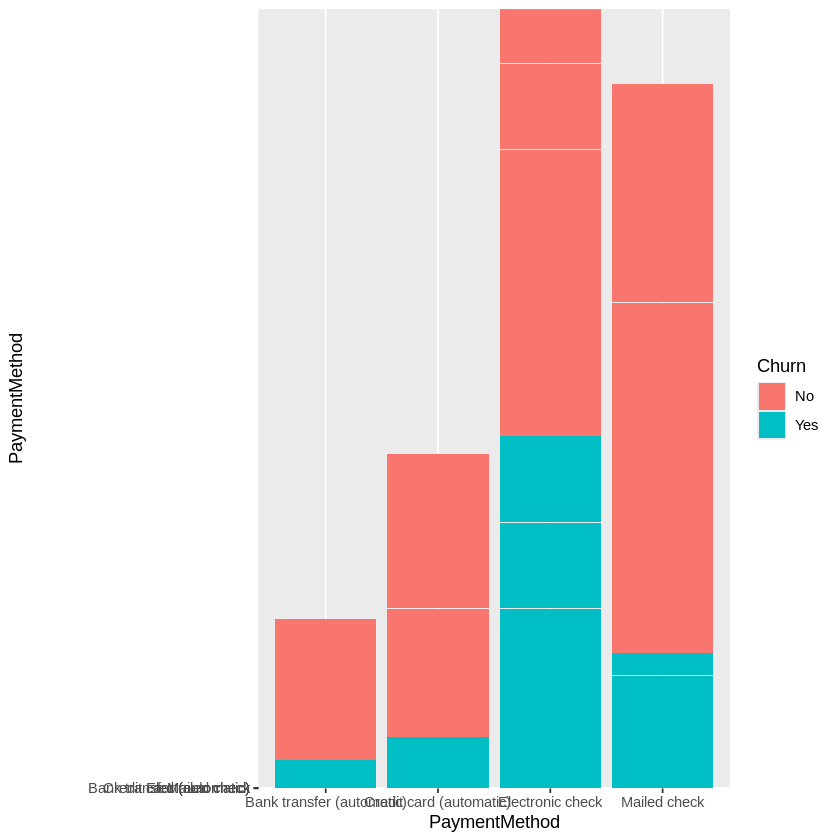

In [ ]:
ggplot(dados_1, aes(y=gender, x=gender, fill=Churn)) +
  geom_bar(stat="identity")

ggplot(dados_1, aes(y=Partner, x=Partner, fill=Churn)) +
  geom_bar(stat="identity")

ggplot(dados_1, aes(y=Dependents, x=Dependents, fill=Churn)) +
  geom_bar(stat="identity")

ggplot(dados_1, aes(y=PhoneService, x=PhoneService, fill=Churn)) +
  geom_bar(stat="identity")

ggplot(dados_1, aes(y=MultipleLines, x=MultipleLines, fill=Churn)) +
  geom_bar(stat="identity")

ggplot(dados_1, aes(y=InternetService, x=InternetService, fill=Churn)) +
  geom_bar(stat="identity")

ggplot(dados_1, aes(y=OnlineSecurity, x=OnlineSecurity, fill=Churn)) +
  geom_bar(stat="identity")

ggplot(dados_1, aes(y=OnlineBackup, x=OnlineBackup, fill=Churn)) +
  geom_bar(stat="identity")

ggplot(dados_1, aes(y=PaymentMethod, x=PaymentMethod, fill=Churn)) +
  geom_bar(stat="identity")

Verificar a classificacao das variaveis numericas

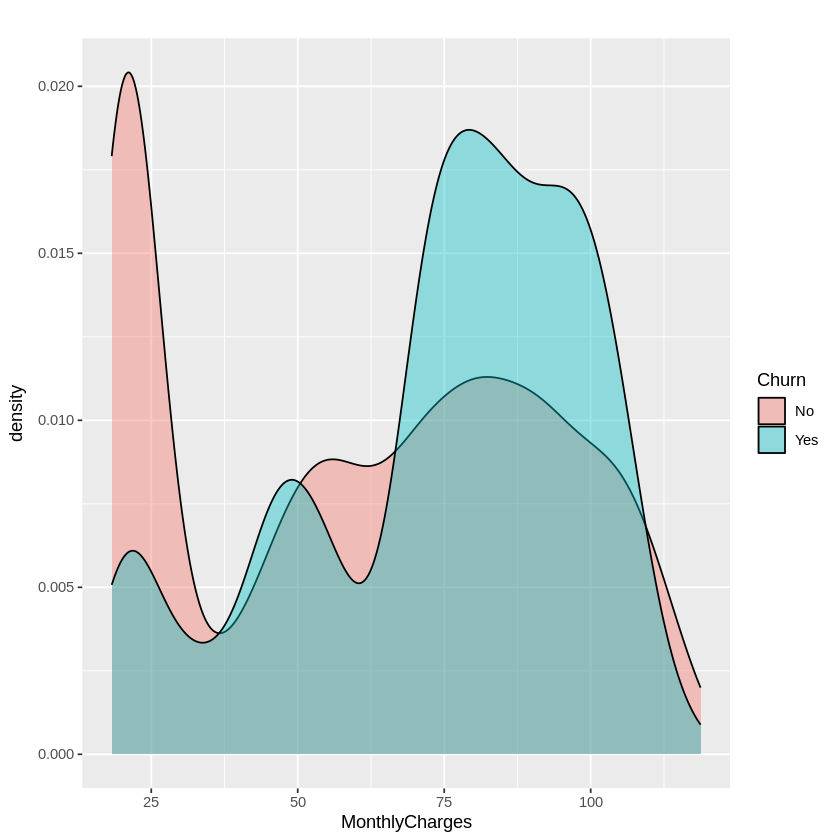

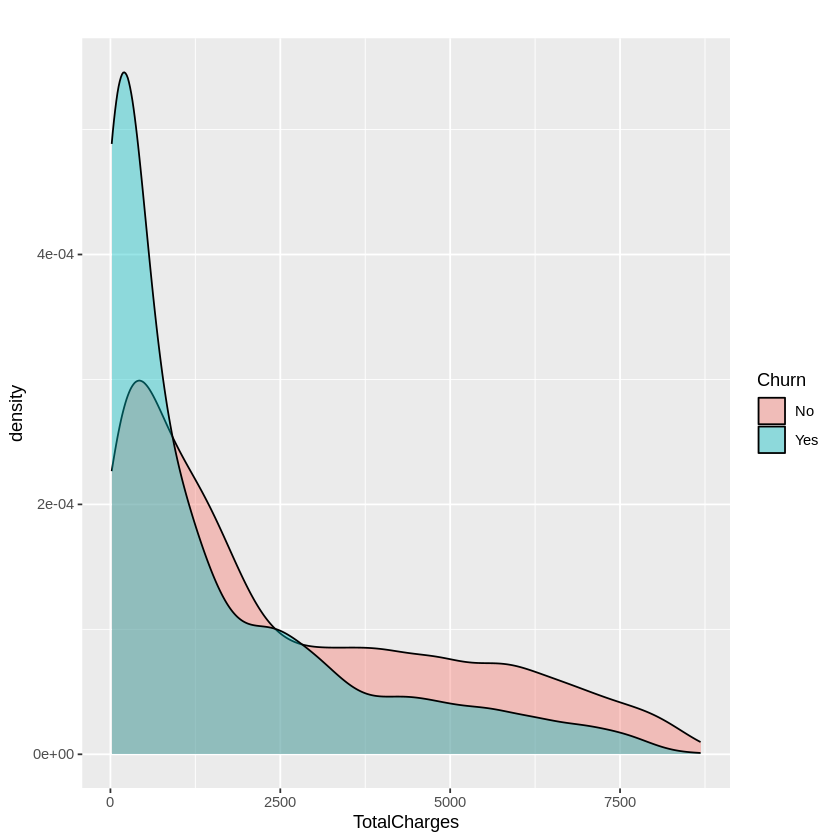

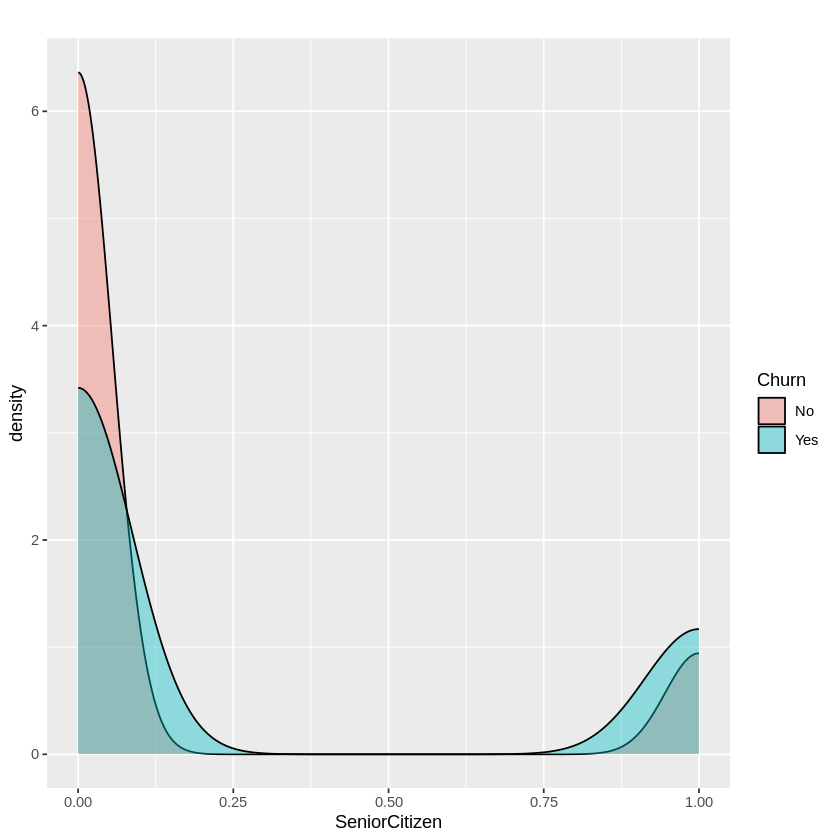

In [ ]:
ggplot(dados_1,
       aes(x=MonthlyCharges,
          fill=Churn)) +
    geom_density(alpha=0.4) +
    labs(title="")

  ggplot(dados_1,
       aes(x=TotalCharges,
          fill=Churn)) +
    geom_density(alpha=0.4) +
    labs(title="")

  ggplot(dados_1,
       aes(x=SeniorCitizen,
          fill=Churn)) +
    geom_density(alpha=0.4) +
    labs(title="")



In [ ]:
summary(dados_1)

      customerID      gender     SeniorCitizen    Partner    Dependents
 0002-ORFBO:   1   Female:3483   Min.   :0.0000   No :3639   No :4933  
 0003-MKNFE:   1   Male  :3549   1st Qu.:0.0000   Yes:3393   Yes:2099  
 0004-TLHLJ:   1                 Median :0.0000                        
 0011-IGKFF:   1                 Mean   :0.1624                        
 0013-EXCHZ:   1                 3rd Qu.:0.0000                        
 0013-MHZWF:   1                 Max.   :1.0000                        
 (Other)   :7026                                                       
     tenure      PhoneService          MultipleLines     InternetService
 Min.   : 1.00   No : 680     No              :3385   DSL        :2416  
 1st Qu.: 9.00   Yes:6352     No phone service: 680   Fiber optic:3096  
 Median :29.00                Yes             :2967   No         :1520  
 Mean   :32.42                                                          
 3rd Qu.:55.00                                             

Transformar dados qualitativos para quantitativos (variaveis binarias)

In [ ]:
dados_quant <- dados_1
colnames (dados_quant)
dados_quant %>%
  mutate(customerID = NULL,
    PhoneService = as.factor(ifelse(PhoneService=="Yes",1,0)),
    Partner = as.factor(ifelse(Partner=="Yes",1,0)),
    PaperlessBilling = as.factor(ifelse(PaperlessBilling=="Yes",1,0)),
    Dependents = NULL,
    Churn = as.factor(ifelse(Churn=="Yes",1,0)),
    ) -> dados_quant
glimpse(dados_quant)

[1] "customerID"       "gender"           "SeniorCitizen"    "Partner"         
 [5] "Dependents"       "tenure"           "PhoneService"     "MultipleLines"   
 [9] "InternetService"  "OnlineSecurity"   "OnlineBackup"     "DeviceProtection"
[13] "TechSupport"      "StreamingTV"      "StreamingMovies"  "Contract"        
[17] "PaperlessBilling" "PaymentMethod"    "MonthlyCharges"   "TotalCharges"    
[21] "Churn"

Rows: 7,032
Columns: 19
$ gender           <fct> Female, Male, Male, Male, Female, Female, Male, Femal…
$ SeniorCitizen    <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Partner          <fct> 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,…
$ tenure           <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, 62, 13, 16, 58, 49, 2…
$ PhoneService     <fct> 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ MultipleLines    <fct> No phone service, No, No, No phone service, No, Yes, …
$ InternetService  <fct> DSL, DSL, DSL, DSL, Fiber optic, Fiber optic, Fiber o…
$ OnlineSecurity   <fct> No, Yes, Yes, Yes, No, No, No, Yes, No, Yes, Yes, No …
$ OnlineBackup     <fct> Yes, No, Yes, No, No, No, Yes, No, No, Yes, No, No in…
$ DeviceProtection <fct> No, Yes, No, Yes, No, Yes, No, No, Yes, No, No, No in…
$ TechSupport      <fct> No, No, No, Yes, No, No, No, No, Yes, No, No, No inte…
$ StreamingTV      <fct> No, No, No, No, No, Yes, Yes, No, Yes, No, No, No int…
$ StreamingMovie

Variaveis Dummy e exclusao de variaveis qualitativas

In [ ]:
dummy_dados <- dados_quant %>% select(InternetService, Contract, PaymentMethod, MultipleLines, OnlineBackup, OnlineSecurity, DeviceProtection, StreamingTV, StreamingMovies, TechSupport)

dummy <- dummyVars(~ ., data = dummy_dados, fullRank = T)

dummy_dados <- predict(dummy, dummy_dados)
dados_quant1 <- bind_cols(dados_quant, dummy_dados)

dados_quant1 %>%
  rename( InternetService.Fiberoptic = `InternetService.Fiber optic`,
  Contract.Oneyear = `Contract.One year`,
  Contract.Twoyear = `Contract.Two year`,
  PaymentMethod.Creditcard = `PaymentMethod.Credit card (automatic)`,
  PaymentMethod.Electronic = `PaymentMethod.Electronic check`,
  PaymentMethod.Mailed = `PaymentMethod.Mailed check`,
  MultipleLines.NoService = `MultipleLines.No phone service`,
  OnlineBackup.NoService = `OnlineBackup.No internet service`,
  OnlineSecurity.NoService = `OnlineSecurity.No internet service`,
  DeviceProtection.NoService = `DeviceProtection.No internet service`,
  StreamingTV.NoService = `StreamingTV.No internet service`,
  StreamingMovies.NoService = `StreamingTV.No internet service`,
  TechSupport.NoService = `TechSupport.No internet service`) -> dados_quant1

  dados_quant1 %>%
    mutate(gender = NULL,
    InternetService = NULL,
    Contract=NULL,
    PaymentMethod=NULL,
    PaymentMOnlineBackupethod=NULL,
    OnlineSecurity=NULL,
    StreamingTV=NULL,
    StreamingMovies=NULL,
    MultipleLines=NULL,
    OnlineBackup=NULL,
    DeviceProtection=NULL,
    TechSupport=NULL) -> dados_quant1

glimpse(dados_quant1)

Rows: 7,032
Columns: 29
$ SeniorCitizen                         <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Partner                               <fct> 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,…
$ tenure                                <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, …
$ PhoneService                          <fct> 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,…
$ PaperlessBilling                      <fct> 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,…
$ MonthlyCharges                        <dbl> 29.85, 56.95, 53.85, 42.30, 70.7…
$ TotalCharges                          <dbl> 29.85, 1889.50, 108.15, 1840.75,…
$ Churn                                 <fct> 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,…
$ InternetService.Fiberoptic            <dbl> 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,…
$ InternetService.No                    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Contract.Oneyear                      <dbl> 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,…
$ Contract.Twoyear                      <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ PaymentMethod.

### Correlacao dos dados

Todos com <fct> serao transformados em numerico

Rows: 7,032
Columns: 29
$ SeniorCitizen                         <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Partner                               <dbl> 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2,…
$ tenure                                <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, …
$ PhoneService                          <dbl> 1, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2,…
$ PaperlessBilling                      <dbl> 2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2,…
$ MonthlyCharges                        <dbl> 29.85, 56.95, 53.85, 42.30, 70.7…
$ TotalCharges                          <dbl> 29.85, 1889.50, 108.15, 1840.75,…
$ Churn                                 <dbl> 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 1,…
$ InternetService.Fiberoptic            <dbl> 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,…
$ InternetService.No                    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Contract.Oneyear                      <dbl> 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,…
$ Contract.Twoyear                      <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ PaymentMethod.

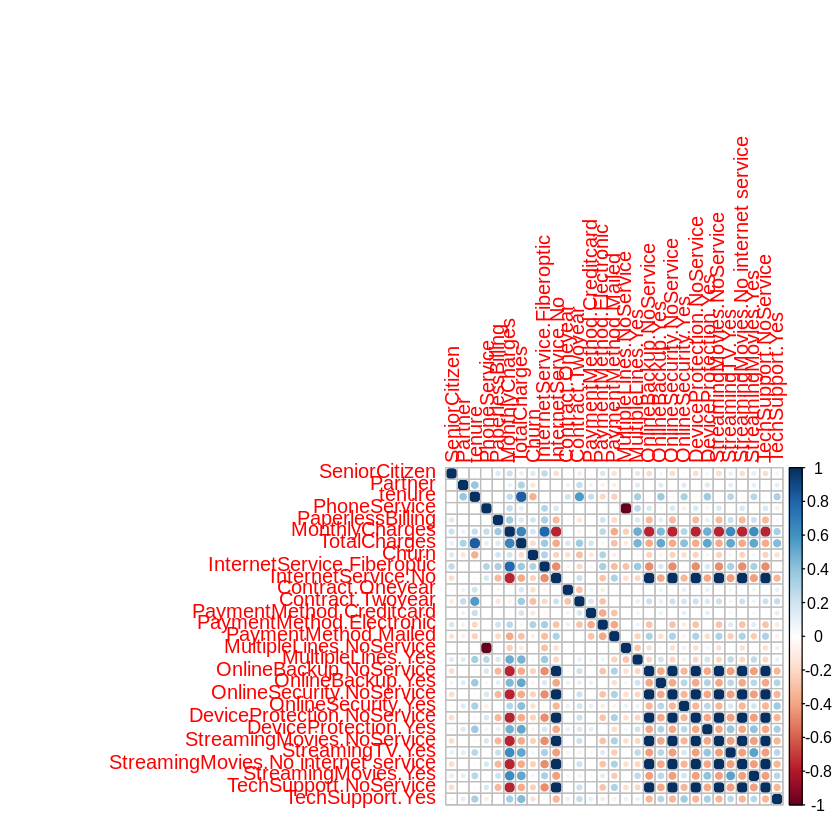

In [ ]:
dados_quant1 %>%
  mutate( Partner = as.numeric(Partner),
    PhoneService = as.numeric(PhoneService),
    PaperlessBilling = as.numeric(PaperlessBilling),
    Churn = as.numeric(Churn)) -> dados_num

glimpse(dados_num)

corrplot(cor(dados_num), method="circle")

Rows: 7,032
Columns: 29
$ SeniorCitizen                         <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Partner                               <dbl> 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2,…
$ tenure                                <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, …
$ PhoneService                          <dbl> 1, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2,…
$ PaperlessBilling                      <dbl> 2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2,…
$ MonthlyCharges                        <dbl> 29.85, 56.95, 53.85, 42.30, 70.7…
$ TotalCharges                          <dbl> 29.85, 1889.50, 108.15, 1840.75,…
$ Churn                                 <dbl> 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 1,…
$ InternetService.Fiberoptic            <dbl> 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,…
$ InternetService.No                    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Contract.Oneyear                      <dbl> 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,…
$ Contract.Twoyear                      <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ PaymentMethod.

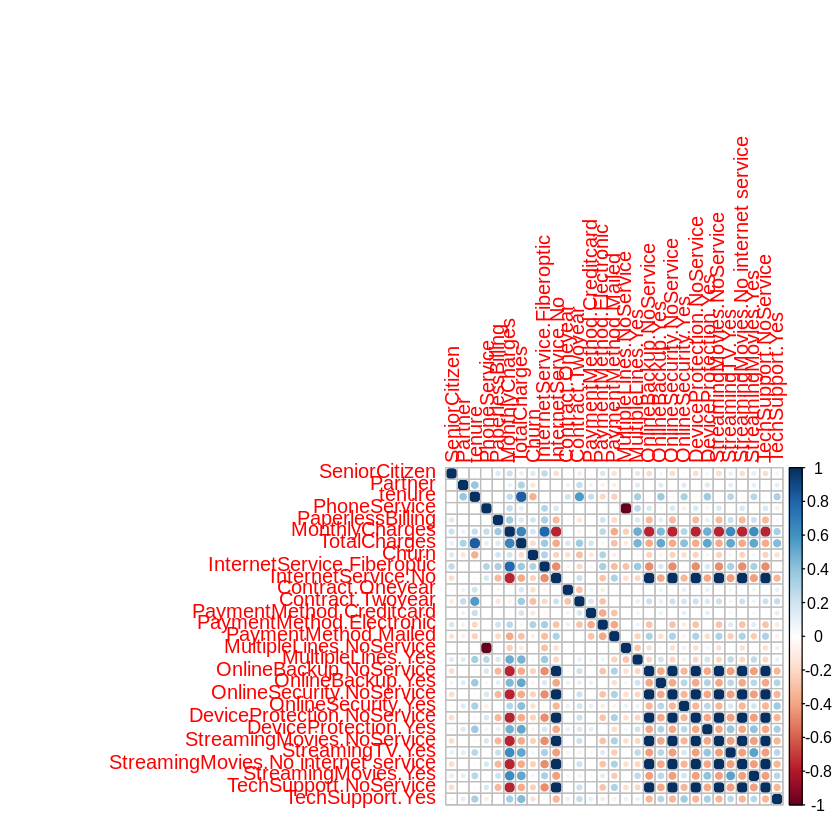

In [ ]:
dados_quant1 %>%
  mutate( Partner = as.numeric(Partner),
    PhoneService = as.numeric(PhoneService),
    PaperlessBilling = as.numeric(PaperlessBilling),
    Churn = as.numeric(Churn)) -> dados_num

glimpse(dados_num)

corrplot(cor(dados_num), method="circle")

Rows: 7,032
Columns: 29
$ SeniorCitizen                         <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Partner                               <dbl> 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2,…
$ tenure                                <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, …
$ PhoneService                          <dbl> 1, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2,…
$ PaperlessBilling                      <dbl> 2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2,…
$ MonthlyCharges                        <dbl> 29.85, 56.95, 53.85, 42.30, 70.7…
$ TotalCharges                          <dbl> 29.85, 1889.50, 108.15, 1840.75,…
$ Churn                                 <dbl> 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 1,…
$ InternetService.Fiberoptic            <dbl> 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,…
$ InternetService.No                    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Contract.Oneyear                      <dbl> 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,…
$ Contract.Twoyear                      <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ PaymentMethod.

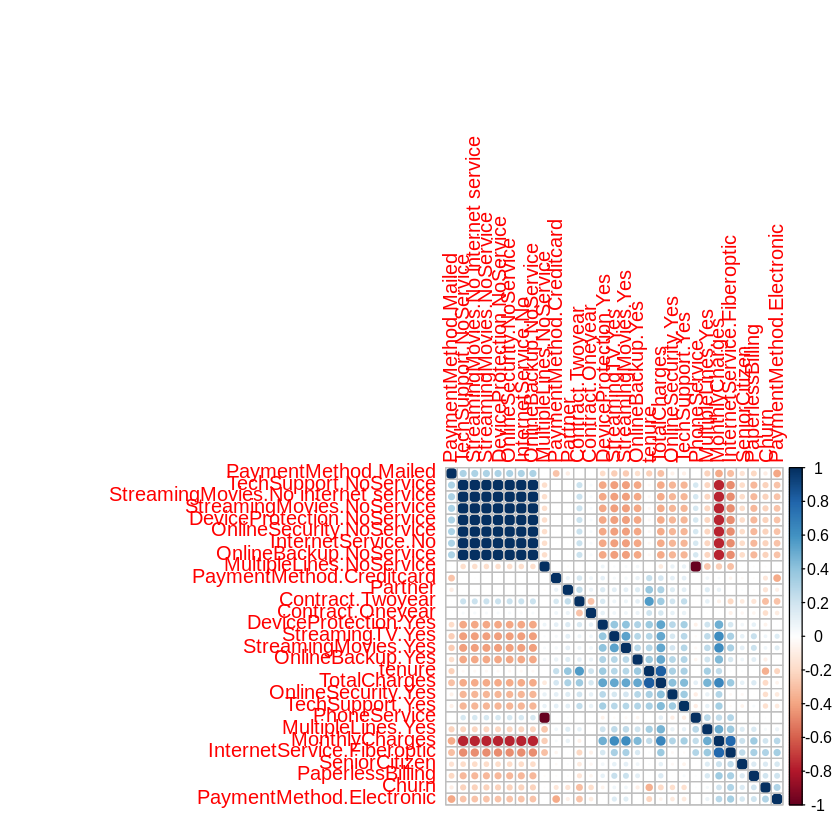

In [ ]:
dados_num %>%
  mutate(Dependents = NULL) -> dados_num_1

glimpse(dados_num_1)

corrplot(cor(dados_num_1), order = "hclust", method="circle")

Quanto mais azul ou vermelho, mais os dados estao correlacionados

Azul = positiva

Vermelho = negativa

Retirar as variaveis correlacionadas

In [ ]:
dados_num_1 %>%
  mutate(StreamingMovies.NoService=NULL,
  StreamingTV.NoService=NULL,
  DeviceProtection.NoService=NULL,
  OnlineSecurity.NoService=NULL,
  InternetService.NoService=NULL,
  OnlineBackup.NoService=NULL) -> dados_num_1

### Balancear a base de dados

In [ ]:
# Original distribution of Churn in dados_quant1
cat("\nOriginal Churn distribution in dados_quant1:\n")
print(table(dados_quant1$Churn))

# Filter for non-churn (Churn == "0") and sample
dados_quant1 %>%
  filter(Churn == "0") %>%
  sample_n(1869) -> dados_quant_0

# Filter for churn (Churn == "1")
dados_quant1 %>%
  filter(Churn == "1") -> dados_quant_1

# Bind the rows to create the balanced dataset
dados_num_balanc <- bind_rows(dados_quant_0, dados_quant_1)

# Verify the Churn distribution in the balanced dataset
cat("\nChurn distribution in dados_num_balanc (after balancing):\n")
print(table(dados_num_balanc$Churn))

# Remove redundant and potentially confusing code for dados_num_1
# (The original intent was to balance dados_num_balanc from dados_quant1, not dados_num_1)

# No further action on dados_num_1 here, as dados_num_balanc is correctly formed from dados_quant1

# Check Churn distribution in dados_num_balanc again after the explicit balancing
dados_num_balanc %>%
  select(Churn) %>%
  group_by(Churn) %>%
  summarise(n=n())


Original Churn distribution in dados_quant1:

   0    1 
5163 1869 

Churn distribution in dados_num_balanc (after balancing):

   0    1 
1869 1869 


Churn,n
<fct>,<int>
0,1869
1,1869


Stepwize - Quais variaveis agregam ao modelo

In [ ]:
dados_num_balanc_fixed <- dados_num_balanc

modelo_teste1 <- glm(data = dados_num_balanc_fixed, Churn ~ .,family=binomial)
step(modelo_teste1)
summary(modelo_teste1)

Start:  AIC=3649.31
Churn ~ SeniorCitizen + Partner + tenure + PhoneService + PaperlessBilling + 
    MonthlyCharges + TotalCharges + InternetService.Fiberoptic + 
    InternetService.No + Contract.Oneyear + Contract.Twoyear + 
    PaymentMethod.Creditcard + PaymentMethod.Electronic + PaymentMethod.Mailed + 
    MultipleLines.NoService + MultipleLines.Yes + OnlineBackup.NoService + 
    OnlineBackup.Yes + OnlineSecurity.NoService + OnlineSecurity.Yes + 
    DeviceProtection.NoService + DeviceProtection.Yes + StreamingMovies.NoService + 
    StreamingTV.Yes + `StreamingMovies.No internet service` + 
    StreamingMovies.Yes + TechSupport.NoService + TechSupport.Yes


Step:  AIC=3649.31
Churn ~ SeniorCitizen + Partner + tenure + PhoneService + PaperlessBilling + 
    MonthlyCharges + TotalCharges + InternetService.Fiberoptic + 
    InternetService.No + Contract.Oneyear + Contract.Twoyear + 
    PaymentMethod.Creditcard + PaymentMethod.Electronic + PaymentMethod.Mailed + 
    MultipleLines


Call:  glm(formula = Churn ~ SeniorCitizen + tenure + PhoneService + 
    PaperlessBilling + MonthlyCharges + TotalCharges + InternetService.Fiberoptic + 
    InternetService.No + Contract.Oneyear + Contract.Twoyear + 
    PaymentMethod.Electronic + MultipleLines.Yes + DeviceProtection.Yes + 
    StreamingTV.Yes + StreamingMovies.Yes, family = binomial, 
    data = dados_num_balanc_fixed)

Coefficients:
               (Intercept)               SeniorCitizen  
                  2.491833                    0.278556  
                    tenure               PhoneService1  
                 -0.055458                    0.762594  
         PaperlessBilling1              MonthlyCharges  
                  0.254028                   -0.061366  
              TotalCharges  InternetService.Fiberoptic  
                  0.000305                    2.265217  
        InternetService.No            Contract.Oneyear  
                 -2.422519                   -0.655666  
          Contract.Two


Call:
glm(formula = Churn ~ ., family = binomial, data = dados_num_balanc_fixed)

Coefficients: (7 not defined because of singularities)
                                        Estimate Std. Error z value Pr(>|z|)
(Intercept)                            2.1756385  1.0470009   2.078 0.037712
SeniorCitizen                          0.2775900  0.1095311   2.534 0.011266
Partner1                              -0.0608736  0.0890766  -0.683 0.494364
tenure                                -0.0553533  0.0068283  -8.106 5.21e-16
PhoneService1                          0.4409565  0.8312175   0.530 0.595769
PaperlessBilling1                      0.2473247  0.0935314   2.644 0.008186
MonthlyCharges                        -0.0451409  0.0407476  -1.108 0.267941
TotalCharges                           0.0003063  0.0000794   3.858 0.000114
InternetService.Fiberoptic             1.8443299  1.0224395   1.804 0.071254
InternetService.No                    -2.0174691  1.0358619  -1.948 0.051460
Contract.Oneyea

### Validacao cruzada

Avalia a capacidade de generalizacao do modelo.

Eh denominado k-fold e divide o conjunto total de dados em k subconjuntos mutuamente exclusivos do mesmo tamanho e um subconjunto eh utilizado como teste e os k-1 restantes sao utilizados para estimacao dos parametros, fazendo o calculo da acuracia do modelo.

O processo eh realizado k vezes alternando de forma circular o subconjunto de testes.

In [ ]:
trainIndex <- createDataPartition(dados_num_balanc$Churn, p = .8,
                                  list=FALSE,
                                  times=1)

vivoTrain <- dados_num_balanc[trainIndex,]
vivoTest <- dados_num_balanc[-trainIndex,]

Treinar a base

In [ ]:
set.seed(150)

glm_model = train(Churn ~ SeniorCitizen + tenure +
    PaperlessBilling + MonthlyCharges + TotalCharges + InternetService.Fiberoptic +
    Contract.Oneyear + Contract.Twoyear +
    PaymentMethod.Electronic + MultipleLines.Yes + OnlineSecurity.Yes +
    StreamingTV.Yes + StreamingMovies.Yes + TechSupport.NoService,
    data= vivoTrain,
    method="glm",
    trControl = trainControl(method = "cv"),
    family = "binomial")

summary(glm_model)
varImp(glm_model)


Call:
NULL

Coefficients:
                             Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 1.660e+00  3.706e-01   4.478 7.53e-06 ***
SeniorCitizen               2.932e-01  1.222e-01   2.399 0.016459 *  
tenure                     -5.657e-02  7.487e-03  -7.556 4.14e-14 ***
PaperlessBilling1           2.635e-01  1.044e-01   2.525 0.011583 *  
MonthlyCharges             -2.821e-02  7.773e-03  -3.629 0.000285 ***
TotalCharges                2.888e-04  8.821e-05   3.274 0.001060 ** 
InternetService.Fiberoptic  1.538e+00  2.514e-01   6.119 9.42e-10 ***
Contract.Oneyear           -7.100e-01  1.406e-01  -5.050 4.41e-07 ***
Contract.Twoyear           -1.333e+00  2.095e-01  -6.362 1.99e-10 ***
PaymentMethod.Electronic    4.913e-01  9.904e-02   4.961 7.03e-07 ***
MultipleLines.Yes           2.992e-01  1.253e-01   2.388 0.016924 *  
OnlineSecurity.Yes         -2.688e-01  1.236e-01  -2.174 0.029710 *  
StreamingTV.Yes             4.616e-01  1.409e-01   3.276 0.0010

glm variable importance

                           Overall
tenure                     100.000
Contract.Twoyear            77.814
InternetService.Fiberoptic  73.291
TechSupport.NoService       70.677
Contract.Oneyear            53.438
PaymentMethod.Electronic    51.772
MonthlyCharges              27.032
StreamingTV.Yes             20.469
TotalCharges                20.441
StreamingMovies.Yes         18.892
PaperlessBilling1            6.515
SeniorCitizen                4.174
MultipleLines.Yes            3.984
OnlineSecurity.Yes           0.000

Testar a base

Rows: 2,992
Columns: 1
$ reg_log_pred <fct> cliente, cliente, evadido, cliente, cliente, evadido, cli…

Summary of predicted probabilities for 'evadido' class (reg_log_prob$`1`):
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.004664 0.205243 0.540931 0.500000 0.790158 0.940428 

Counts of Predicted Classes (reg_log_pred_final):
reg_log_pred_final
cliente evadido 
   1389    1603 

Counts of Reference Classes (vivoTrain_Churn_ref):
vivoTrain_Churn_ref
cliente evadido 
   1496    1496 


          Reference
Prediction cliente evadido
   cliente    1098     291
   evadido     398    1205

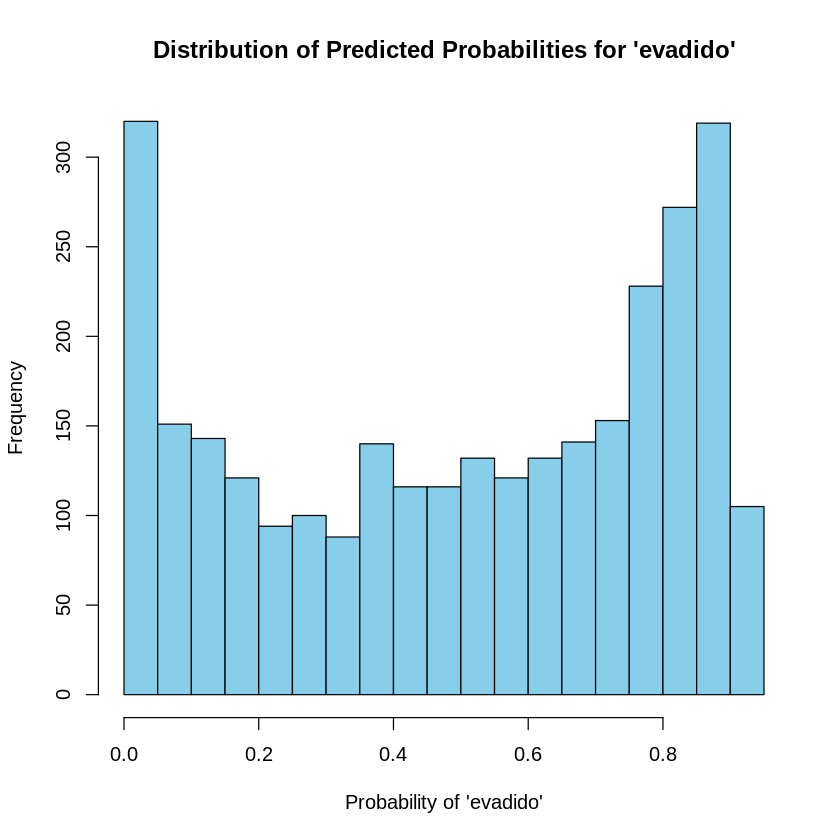

In [ ]:
reg_log_prob <- predict(glm_model, vivoTrain, type = "prob")

# Define the common levels for both factors
common_levels <- c("cliente", "evadido")

# Extract probabilities for the '1' class (assuming '1' is the positive class for Churn)
reg_log_pred_binary <- ifelse(reg_log_prob$`1` >= 0.5, 1, 0)

# Convert binary predictions (0, 1) to factor levels "evadido", "cliente"
# Ensure all possible levels are defined for the factor
reg_log_pred_final <- factor(ifelse(reg_log_pred_binary == 1, "evadido", "cliente"), levels = common_levels)

# Prepare the reference variable (vivoTrain$Churn) to match the prediction levels
# vivoTrain$Churn currently has factor levels "0" and "1"
# Ensure all possible levels are defined for the factor, converting to character for robust comparison
vivoTrain_Churn_ref <- factor(ifelse(as.character(vivoTrain$Churn) == "1", "evadido", "cliente"), levels = common_levels)

# Create reg_log_pred1 data frame for glimpse, as in original code
reg_log_pred1 <- data.frame(reg_log_pred = reg_log_pred_final)
glimpse(reg_log_pred1)

# --- Diagnostics for model performance ---
# Print summary statistics of the predicted probabilities for the positive class ('1' / 'evadido')
cat("\nSummary of predicted probabilities for 'evadido' class (reg_log_prob$`1`):\n")
print(summary(reg_log_prob$`1`))

# Plot histogram of predicted probabilities
hist(reg_log_prob$`1`, main="Distribution of Predicted Probabilities for 'evadido'",
     xlab="Probability of 'evadido'", breaks=30, col="skyblue", border="black")

# Print counts of predicted classes
cat("\nCounts of Predicted Classes (reg_log_pred_final):\n")
print(table(reg_log_pred_final))

# Print counts of reference classes
cat("\nCounts of Reference Classes (vivoTrain_Churn_ref):\n")
print(table(vivoTrain_Churn_ref))

# Perform confusion matrix
matrix_reg <- confusionMatrix(data = reg_log_pred1$reg_log_pred, reference = vivoTrain_Churn_ref, positive = "evadido")
matrix_reg$table

metrics <- data.frame(matrix_reg$byClass)

In [ ]:
metrics

,matrix_reg.byClass
,<dbl>
Sensitivity,0.8054813
Specificity,0.7339572
Pos Pred Value,0.7517155
Neg Pred Value,0.7904968
Precision,0.7517155
Recall,0.8054813
F1,0.7776702
Prevalence,0.5000000
Detection Rate,0.4027406
